<a href="https://colab.research.google.com/github/gleo1973/tp-laboratorio-mcag-1c2026/blob/main/Laboratorio_TP_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Universidad de Buenos Aires · Facultad de Ciencias Económicas  
Tecnicatura Universitaria en Gestión y Análisis de Datos en Organizaciones*

# **Trabajo Práctico Grupal**
Exploración, análisis y presentación de datos reales asistida por IA  

## Análisis y comparación de los equipos de la Copa Mundial de Fútbol 2026.

*Por Leonardo Gomez, Fernando Morichetti y Carla Garibotti.*

---




# Análisis Exploratorio de datos

## Importacion de Librerias

En este bloque se importan las principales librerias de Python que serán utilizadas a lo largo del trabajo para el procesamiento, análisis y visualización de los datos. 

Estas herramientas conforman el entorno de trabajo principal del proyecto y permiten desarrollar tanto el análisis exploratorio inicial como la aplicación de conceptos cuantitativos vistos en la materia.

In [1]:
import pandas as pd #para manejo de archivos de datos
import numpy as np #para hacer operaciones matemáticas
import matplotlib.pyplot as plt #para hacer gráficos
import seaborn as sns #para hacer gráficos

import sympy as sp #para hacer cálculos simbólicos
from scipy.optimize import curve_fit #libreria para encontrar la curva que mejor se ajusta a los datos
from scipy.stats import pearsonr #libreria para calcular el coeficiente de correlación de Pearson


## Carga de datasets principales

En este bloque importamos el dataset que formará la base del análisis. Esta base constituye la fuente principal del análisis ya que nos otorga las variables principales para el análisis sobre el rendimiento de las distintas selecciones que participan del Campeonato Mundial de Futbol 2026.


In [2]:
# Fuente: https://www.kaggle.com/datasets/harrachimustapha/fifa-world-cup-team-dataset consultada el 21/05/2026

df_paises = pd.read_csv("datos/raw/paises.csv")

### Exploracion inicial

Consultamos la dimensión del dataset, con el objetivo de conocer la cantidad de filas y columnas disponibles en la base de datos. La cantidad de filas debe  contener 48 filas, correspondientes a los 48 equipos

In [3]:
df_paises.shape

(48, 24)

Consultamos las columnas presentes en el dataset con el objetivo de identificar las variables disponibles para el análisis.

In [4]:
df_paises.columns

Index(['version', 'team', 'continent', 'is_host', 'goals_scored_last_4y',
       'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y',
       'draws_last_4y', 'world_cup_titles_before',
       'squad_total_market_value_eur', 'fifa_rank_pre_tournament',
       'fifa_points_pre_tournament', 'squad_avg_age',
       'world_cup_participations_before', 'groups_passed_before',
       'round16_before', 'quarterfinals_before', 'semifinals_before',
       'finals_before', 'winner', 'finalist', 'semi_finalist',
       'quarter_finalist'],
      dtype='object')

Visualizamos las primeras filas. Como tiene muchas columnas, vamos a transponer la tabla con el objetivo de facilitar la lectura de los campos y sus respectivos valores.

In [6]:
df_paises.head().T

,0,1,2,3,4
version,2026,2026,2026,2026,2026
team,France,Spain,Argentina,England,Portugal
continent,Europe,Europe,South America,Europe,Europe
is_host,0,0,0,0,0
goals_scored_last_4y,85,104,80,82,98
goals_received_last_4y,32,32,14,23,31
wins_last_4y,25,29,30,26,26
losses_last_4y,6,2,4,6,5
draws_last_4y,7,8,3,7,7
world_cup_titles_before,2,1,3,1,0


Vemos que los equipos están organizados por posición en el ranking; el índice coincide con la misma. Visualizamos ahora las últimas filas para confirmarlo, también con la tabla transpuesta para su mejor visualización.

In [7]:
df_paises.tail().T

,43,44,45,46,47
version,2026,2026,2026,2026,2026
team,Cape Verde,Ghana,Cura?o,Haiti,New Zealand
continent,Africa,Africa,North America,North America,Oceania
is_host,0,0,0,0,0
goals_scored_last_4y,46,46,55,71,63
goals_received_last_4y,39,42,39,37,32
wins_last_4y,16,12,12,16,13
losses_last_4y,10,13,10,8,12
draws_last_4y,12,9,10,8,6
world_cup_titles_before,0,0,0,0,0


Vemos que la tabla tiene distintos valores:  
- version: refiere a la versión del torneo FIFA sobre el cuál trata la información.  
- team: identifica al equipo/plantel nacional.  
- continent: de qué continente es el equipo.  
- is_host: si es el anfitrión del torneo en el año indicado en "version".  
  
Y luego hay datos históricos sobre el desempeño de cada plantel:  
- goals_scored_last_4y: goles marcados en los últimos 4 años.  
- goals_received_last_4y: goles recibimos en los últimos 4 años.  
- wins_last_4y: victorias en los últimos 4 años.  
- losses_last_4y: pérdidas en los últimos 4 años.  
- draws_last_4y: empates en los últimos 4 años.  
- world_cup_titles_before: veces que el plantel ha ganado el torneo.  
- squad_total_market_value_eur: valor de mercado del equipo en euros.  
- fifa_rank_pre_tournament: posición en el ranking FIFA antes del comienzo del torneo.  
- fifa_points_pre_tournament: puntaje FIFA antes del comienzo del torneo.  
- squad_avg_age: edad promedio de los jugadores.  
- world_cup_participations_before: cuántas veces ha participado en la copa del Mundo.  
- groups_passed_before: cuántas veces ha superado la fase de grupos históricamente.  
- round16_before: cuántas veces ha llegado al top 16 históricamente.  
- quarterfinals_before: cuántos cuartos de finales ha jugado el plantel históricamente.  
- semifinals_before: cuántas semifinales ha jugado el plantel históricamente.  
- finals_before: cuántas finales ha jugado el plantel históricamente.  

Finalmente hay 4 columnas que se completarían luego de finalizado el torneo:  
- winner: si fue el ganador del torneo.  
- finalist: si fue finalista en el torneo.  
- semi_finalist: si fue semifinalista en el torneo.  
- quarter_finalist: si llegó a cuartos de finales en el torneo.  

Contamos los valores vacíos de la tabla.

In [8]:
df_paises.isna().sum()

version                             0
team                                0
continent                           0
is_host                             0
goals_scored_last_4y                0
goals_received_last_4y              0
wins_last_4y                        0
losses_last_4y                      0
draws_last_4y                       0
world_cup_titles_before             0
squad_total_market_value_eur        0
fifa_rank_pre_tournament            0
fifa_points_pre_tournament          0
squad_avg_age                       0
world_cup_participations_before     0
groups_passed_before                0
round16_before                      0
quarterfinals_before                0
semifinals_before                   0
finals_before                       0
winner                             48
finalist                           48
semi_finalist                      48
quarter_finalist                   48
dtype: int64

Como las últimas cuatro columnas son para completar luego del torneo, es esperable que estén vacías.  

Revisamos si hay valores duplicados.

In [9]:
print(f"Cantidad de filas duplicadas: {df_paises.duplicated().sum()}")

Cantidad de filas duplicadas: 0


Revisamos el listado de países. Hay países que son nombrados de formas distintas en distintas bases de datos y como usaremos esta columna para combinar las tablas más adelante, necesitamos saber cómo están escritos.

In [10]:
print(df_paises["team"].unique())

['France' 'Spain' 'Argentina' 'England' 'Portugal' 'Brazil' 'Netherlands'
 'Morocco' 'Belgium' 'Germany' 'Croatia' 'Colombia' 'Senegal' 'Mexico'
 'United States' 'Uruguay' 'Japan' 'Switzerland' 'Iran' 'Turkey' 'Ecuador'
 'Austria' 'South Korea' 'Australia' 'Algeria' 'Egypt' 'Canada' 'Norway'
 'Panama' 'Ivory Coast' 'Sweden' 'Paraguay' 'Czech Republic' 'Scotland'
 'Tunisia' 'DR Congo' 'Uzbekistan' 'Qatar' 'Iraq' 'South Africa'
 'Saudi Arabia' 'Jordan' 'Bosnia and Herzegovina' 'Cape Verde' 'Ghana'
 'Cura?o' 'Haiti' 'New Zealand']


Vemos que un valor (Curaçao) quedó mal escrito, así que vamos a corregir ese valor puntual y luego vamos a revisar que ya no queden valores con "?".

In [12]:
df_paises['team'] = df_paises['team'].replace('Cura?o', 'Curaçao')
print(df_paises[df_paises['team'].str.contains(r'\?', na=False)])

Empty DataFrame
Columns: [version, team, continent, is_host, goals_scored_last_4y, goals_received_last_4y, wins_last_4y, losses_last_4y, draws_last_4y, world_cup_titles_before, squad_total_market_value_eur, fifa_rank_pre_tournament, fifa_points_pre_tournament, squad_avg_age, world_cup_participations_before, groups_passed_before, round16_before, quarterfinals_before, semifinals_before, finals_before, winner, finalist, semi_finalist, quarter_finalist]
Index: []

[0 rows x 24 columns]


Importamos otro dataset para sumar los datos estadísticos (poblacionales y demográficos).

In [13]:
# Fuente: https://simplemaps.com/data/countries consultada el 22/05/2026


df_info_paises = pd.read_csv("datos/raw/country_info.csv")

Revisamos cuántas filas y columnas tiene. Debería tener más de 250 filas, ya que contiene información sobre todos los países del mundo.

In [14]:
df_info_paises.shape

(253, 18)

También para estaa revisamos si hay valaores duplicados:

In [15]:
print(f"Cantidad de filas duplicadas: {df_paises.duplicated().sum()}")

Cantidad de filas duplicadas: 0


Revisamos qué tipo de información tiene esta tabla:

In [16]:
df_info_paises.head(3).T

,0,1,2
country,China,India,United States
demonym,Chinese,Indian,American
id,CN,IN,US
iso2,CN,IN,US
tld,.cn,.in,.us
currency,Chinese Yuan,Indian Rupee,United States Dollar
population,1413142846.0,1399179585.0,339665118.0
density,147.2,425.6,34.5
area,9596960.0,3287263.0,9833517.0
gdp,17963170.0,3465541.0,25744100.0


Vemos que la tabla cuenta con la siguiente información:
- country: nombre del país.  
- demonym: gentilicio.  
- id: código del país.  
- iso2: código ISO3166-2 (de 2 letras) que identifica cada país.
- tld: código de sitios web del país.  
- currency: moneda oficial.  
- population: población.  
- density: densidad poblacional.  
- area: extensión geográfica del país.  
- gdp: producto bruto interno (PBI) en millones de USD.  
- median_age: mediana de edad.  
- language: idioma oficial.  
- website: web oficial.  
- calling_code: código telefónico del país.  
- driving_side: dirección de manejo vehicular.  
- continent: continente.  
- un_member: si es miembro de la ONU.  
- religion: religión principal.  

Revisamos si cuenta con valores vacíos.

In [17]:
df_info_paises.isna().sum()

country          0
demonym          9
id               1
iso2             4
tld              7
currency         8
population      14
density         16
area            11
gdp             47
median_age      28
language         8
website         13
calling_code    15
driving_side     1
continent        3
un_member        0
religion         6
dtype: int64

Vemos que tiene valores vacíos. No nos preocupa *a priori* porque no es nuestra base principal, solo necesitamos que en el cruce con la base de equipos no queden lugares vacíos, pero saber que hay valores faaltantes nos da la pauta de que tenemos que tener particular cuidado cuando hagamos el cruce.

Hago un merge con los nombres de países para traer la información estadística.  


In [18]:
df_paises_merge = df_paises.merge(
    df_info_paises,
    left_on='team',
    right_on='country',
    how='left'
)
df_paises_merge.head(3).T

,0,1,2
version,2026,2026,2026
team,France,Spain,Argentina
continent_x,Europe,Europe,South America
is_host,0,0,0
goals_scored_last_4y,85,104,80
goals_received_last_4y,32,32,14
wins_last_4y,25,29,30
losses_last_4y,6,2,4
draws_last_4y,7,8,3
world_cup_titles_before,2,1,3


Al hacer un join de tipo "left", toma todos los valores de la primera tabla (la de los equipos) y busca los que coinciden. Si no encuentra coincidencia, deja valores vacíos. Revisamos entonces si quedaron valores vacíos.

In [19]:
df_paises_merge.isna().sum()

version                             0
team                                0
continent_x                         0
is_host                             0
goals_scored_last_4y                0
goals_received_last_4y              0
wins_last_4y                        0
losses_last_4y                      0
draws_last_4y                       0
world_cup_titles_before             0
squad_total_market_value_eur        0
fifa_rank_pre_tournament            0
fifa_points_pre_tournament          0
squad_avg_age                       0
world_cup_participations_before     0
groups_passed_before                0
round16_before                      0
quarterfinals_before                0
semifinals_before                   0
finals_before                       0
winner                             48
finalist                           48
semi_finalist                      48
quarter_finalist                   48
country                             3
demonym                             3
id          

Vemos que quedaron 3 países que no cruzaron. Revisamos cuáles.

In [352]:
sin_cruzar = df_paises_merge[df_paises_merge['country'].isna()][['team']]
print(sin_cruzar)

        team
3    England
33  Scotland
35  DR Congo


Tiene sentido que estén Inglaterra y Escocia porque no son países independientes, sino que forman parte de Reino Unido. Primero vamos a revisar cómo llaman a DR Congo en este dataset para poder modificar el valor. 

In [20]:
print(df_info_paises["country"].unique())

['China' 'India' 'United States' 'Indonesia' 'Pakistan' 'Nigeria' 'Brazil'
 'Bangladesh' 'Russia' 'Mexico' 'Japan' 'Ethiopia' 'Philippines'
 'Democratic Republic of the Congo' 'Egypt' 'Vietnam' 'Iran' 'Germany'
 'Turkey' 'Thailand' 'France' 'United Kingdom' 'Tanzania' 'Italy'
 'South Africa' 'Myanmar' 'Kenya' 'South Korea' 'Colombia' 'Sudan'
 'Uganda' 'Spain' 'Argentina' 'Algeria' 'Ukraine' 'Iraq' 'Afghanistan'
 'Canada' 'Poland' 'Morocco' 'Angola' 'Saudi Arabia' 'Malaysia' 'Ghana'
 'Mozambique' 'Peru' 'Yemen' 'Uzbekistan' 'Nepal' 'Venezuela' 'Cameroon'
 'Ivory Coast' 'Madagascar' 'Australia' 'North Korea' 'Niger' 'Taiwan'
 'Sri Lanka' 'Syria' 'Burkina Faso' 'Mali' 'Malawi' 'Zambia' 'Kazakhstan'
 'Chile' 'Chad' 'Senegal' 'Romania' 'Guatemala' 'Ecuador' 'Netherlands'
 'Cambodia' 'Zimbabwe' 'Benin' 'Guinea' 'Rwanda' 'Burundi' 'Somalia'
 'Bolivia' 'South Sudan' 'Tunisia' 'Belgium' 'Haiti' 'Jordan' 'Cuba'
 'Dominican Republic' 'Czech Republic' 'Sweden' 'Greece' 'Azerbaijan'
 'Portugal' 'Un

In [21]:
df_info_paises['country'] = df_info_paises['country'].replace('Democratic Republic of the Congo', 'DR Congo')

Con eso corregimos el nombre de DR Congo. Escocia e Inglaterra presentan un problema especial porque son dos equipos de un mismo país.  
Como la información no numérica es igual, lo que vamos a hacver es copiar para ambos la información de Reino Unido. A continuación copio la fila de Reino Unido dos veces y le cambio el valor en "country" por Inglaterra y Escocia para que puedan cruzar esos dos equipos.
> ⚠️ *Nota* : Tanto Escocia como Inglaterra tendrán ambos la información de Reino Unido entero así que si sumamos los valores numéricos tendremos que eliminar duplicados.  


In [22]:
fila_uk = df_info_paises[df_info_paises['country'] == 'United Kingdom'].copy()

fila_england = fila_uk.copy()
fila_england['country'] = 'England'

fila_scotland = fila_uk.copy()
fila_scotland['country'] = 'Scotland'

df_info_paises = pd.concat([df_info_paises, fila_england, fila_scotland], ignore_index=True)


Volvemos a intentar el merge y vemos si quedaron valores vacíos.

In [23]:
df_paises_merge = df_paises.merge(
    df_info_paises,
    left_on='team',
    right_on='country',
    how='left'
)
df_paises_merge.isna().sum()

version                             0
team                                0
continent_x                         0
is_host                             0
goals_scored_last_4y                0
goals_received_last_4y              0
wins_last_4y                        0
losses_last_4y                      0
draws_last_4y                       0
world_cup_titles_before             0
squad_total_market_value_eur        0
fifa_rank_pre_tournament            0
fifa_points_pre_tournament          0
squad_avg_age                       0
world_cup_participations_before     0
groups_passed_before                0
round16_before                      0
quarterfinals_before                0
semifinals_before                   0
finals_before                       0
winner                             48
finalist                           48
semi_finalist                      48
quarter_finalist                   48
country                             0
demonym                             0
id          

Vemos que cruzaron todos pero quedaron algunos valores vacíos: "GDP" (PBI, en español) y "calling_code" (código tele´fonico). El segundo no forma parte del análisis pero PBI sí, así que revisamos qué valor está faltando.

In [24]:
print(df_paises_merge[df_paises_merge['gdp'].isna()][['team']])


       team
45  Curaçao


Vemos que el PBI que falta es el de Curaçao así que buscamos y completamos este valor de forma manual consultando el Banco Mundial.  
Según la fuente [NY.GDP.MKTP.CD](https://data.worldbank.org/indicator/NY.GDP.MKTP.CD), el PBI de Curaçao en 2022 fue aproximadamente **3.561 millones de USD**, que es la unidad utilizada en el dataset `country_info.csv`.

In [25]:
# Imputación manual del PBI de Curaçao
# Fuente: Banco Mundial - NY.GDP.MKTP.CD (2022)
# Unidad: millones de USD (igual que el resto del dataset country_info.csv)

df_paises_merge.loc[df_paises_merge["team"] == "Curaçao", "gdp"] = 3561.0


Revisamos que ya no haya valores vacíos para PBI.

In [26]:
print(df_paises_merge[df_paises_merge['gdp'].isna()][['team']])

Empty DataFrame
Columns: [team]
Index: []


Finalizada la exploración de las bases, planteamos la pregunta de investigación:

# Pregunta de investigación

**Pregunta**: ¿El rendimiento deportivo de una selección nacional puede explicarse a partir del nivel de desarrollo económico y demográfico de su país (PBI, PBI per cápita, población, densidad, edad mediana)? Y si no es así, ¿qué variables —del país o del propio plantel— sí muestran relación con ese rendimiento?

**Motivación**: identificar qué variables explican el rendimiento de una selección permite distinguir entre lo modificable y lo inmutable. Las características demográficas y económicas de un país son relativamente estables en el tiempo: si fueran el principal determinante del rendimiento, este estaría en buena medida "predeterminado" y sería difícil de mejorar. En cambio, si el rendimiento resulta independiente de esas características, queda margen para intervenir sobre él mediante decisiones de gestión e inversión. La pregunta ilumina, entonces, hasta qué punto el éxito deportivo es estructural o gestionable.

**Respuesta**: el rendimiento deportivo (medido por el puntaje FIFA) resultó **independiente de las variables económicas y demográficas del país**: ninguna de ellas mostró correlación relevante con el desempeño. En cambio, encontramos dos hallazgos centrales:

1. **Valor del plantel.** Existe una correlación fuerte entre el valor de mercado del plantel y el puntaje FIFA (r ≈ 0,77). Al modelar la relación, el mejor ajuste fue cuadrático y cóncavo hacia abajo, lo que indica rendimientos marginales decrecientes: invertir más en el plantel mejora el puntaje, pero cada euro adicional aporta cada vez menos. 

2. **Variables culturales/geográficas.** El continente de origen y el idioma se asocian al rendimiento (Sudamérica y Europa, y los países de habla hispana, presentan medianas más altas). Estas dimensiones probablemente capturan un mismo factor cultural subyacente y, en parte, se solapan entre sí.

En conjunto, los resultados sugieren que el rendimiento de una selección no está determinado por la riqueza o el tamaño del país, sino que combina una base relativamente "fija" (asociada a factores culturales y geográficos) con un componente modificable mediante inversión en el plantel, sujeta a rendimientos decrecientes.

Teniendo ya toda la información que nos interesa, filtramos para que nos queden las columnas que nos interesan para responder la pregunta.

In [27]:
df_paises_f = df_paises_merge[[
     "team", 
     "continent_x", 
     "squad_total_market_value_eur", 
     "fifa_points_pre_tournament", 
     "squad_avg_age",
     "population", 
     "density",
     "area", 
     "gdp", 
     "median_age", 
     "language", 
     "religion"]].copy()


Armamos un diccionario para renombrar las columnas

In [28]:

columnas = {"team":"pais",
            "continent_x":"continente",
            "squad_total_market_value_eur":"valor_en_euros",
            "fifa_points_pre_tournament":"puntos_FIFA",
            "squad_avg_age":"edad_promedio_equipo",
            "population" : "poblacion",
            "density" : "densidad",
            "area" : "superficie",
            "gdp" : "pbi",
            "median_age" : "edad_mediana_pais",
            "language" : "idioma",
            } #religion se escribe igual en ambos idiomas, asi que no hace falta renombrarla
df_paises_f.rename(columns=columnas,inplace=True)

Generamos una columna de PBI per cápita dividiendo los valores de PBI por la población. Multiplico el valor de PBI por 1000 porque el PBI está en millones de USD; de esta manera el valor de PBI per cápìta queda en miles de dólares.

In [40]:
df_paises_f["pbi_per_capita"] = df_paises_f["pbi"]*1000 / df_paises_f["poblacion"]

Primero vamos a buscar si hay relación en términos matemáticos entre las variables numéricas. A esos fines, primero revisamos los tipos de variables que tenemos.

In [43]:
df_paises_f.dtypes

pais                     object
continente               object
valor_en_euros            int64
puntos_FIFA             float64
edad_promedio_equipo    float64
poblacion               float64
densidad                float64
superficie              float64
pbi                     float64
edad_mediana_pais       float64
idioma                   object
religion                 object
pbi_per_capita          float64
dtype: object

Como vamos a evaluar primero las variables numéricas, vamos a generar un dataframe que no incluya a Inglaterra y Escocia. 

In [59]:
#celda con asistencia de IA. Prompt: "Filtrar el dataframe para quedarme solo con los países que no sean Inglaterra ni Escocia, y luego hacer una copia de ese nuevo dataframe para trabajar con él sin modificar el original"
df_filtrado = df_paises_f[~df_paises_f["pais"].isin(["England", "Scotland"])].copy()

Analizamos ahora las medidas estadisticas de las variables númericas presentes. Redondeamos al primer decimal para simplificar la lectura.

In [60]:
df_filtrado.describe().round(1)

,valor_en_euros,puntos_FIFA,edad_promedio_equipo,poblacion,densidad,superficie,pbi,edad_mediana_pais,pbi_per_capita
count,4.600000e+01,46.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0
mean,2.924137e+08,1576.4,27.2,45978765.3,119.1,1317149.5,1237202.8,34.8,25.4
std,3.194367e+08,155.3,1.1,62484681.1,125.6,2522413.9,3824963.7,8.5,27.8
min,5.300000e+06,1281.6,24.6,152849.0,3.4,444.0,1572.0,16.8,0.1
25%,3.537500e+07,1468.6,26.5,9261432.5,36.7,85238.8,71266.2,29.2,4.3
50%,1.673000e+08,1572.5,27.1,27903006.5,74.1,340412.0,277354.5,34.1,12.4
75%,4.314625e+08,1687.0,27.9,51309324.5,132.9,1104545.0,884945.0,42.4,38.9
max,1.290000e+09,1877.3,29.3,339665118.0,521.1,9984670.0,25744100.0,49.5,103.5


Observamos una gran dispersión en el valor de los equipos (345 M€). Respecto a los indicadores demográficos y económicos también existe una gran heterogeneidad. Vamos a realizar unos histogramas para ver qué formas tienen las distribuciones de las variables.

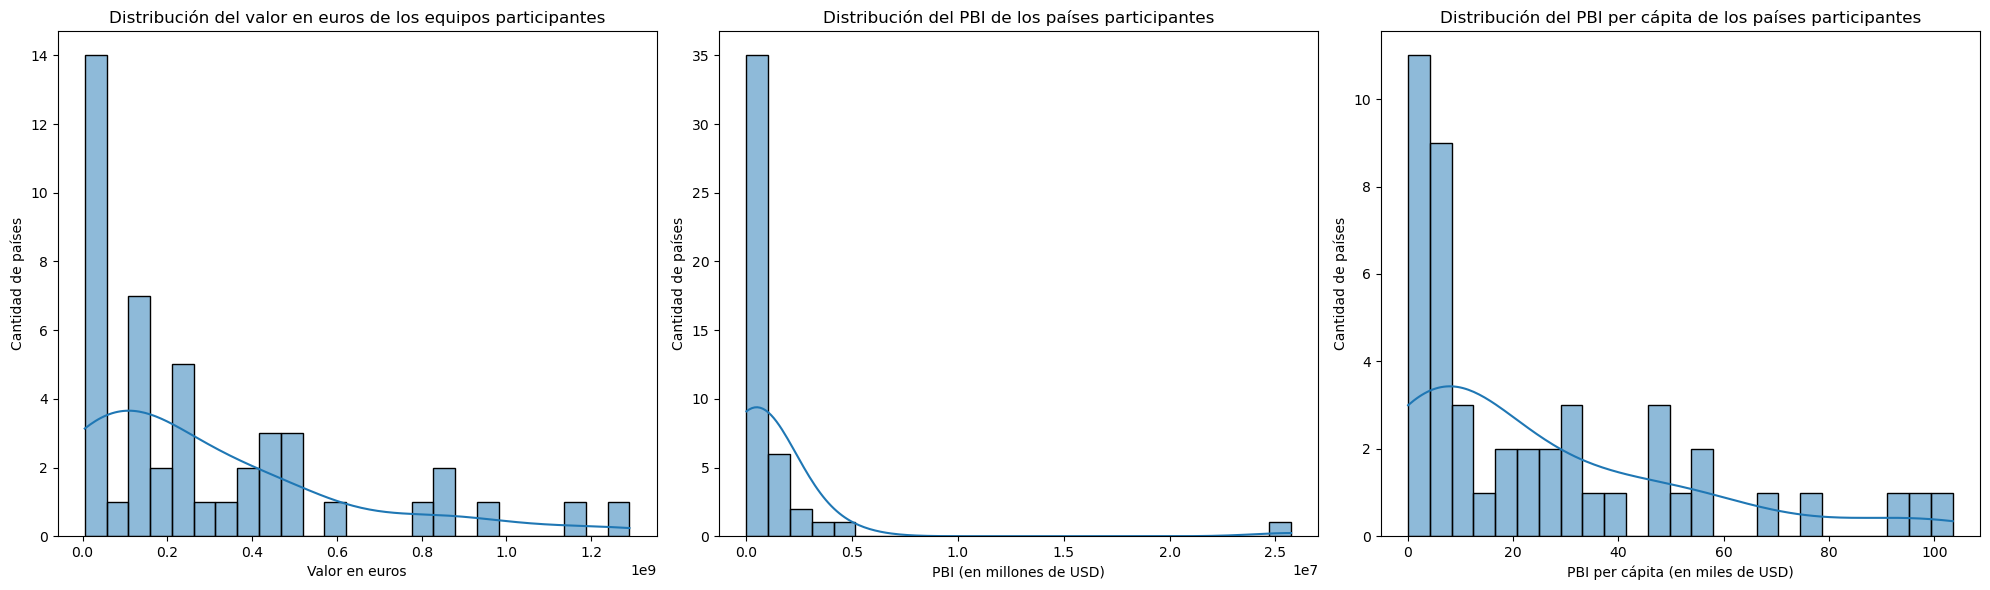

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(df_filtrado["valor_en_euros"], bins=25, kde=True, ax=axes[0])
axes[0].set_title("Distribución del valor en euros de los equipos participantes")
axes[0].set_xlabel("Valor en euros")
axes[0].set_ylabel("Cantidad de países")

sns.histplot(df_filtrado["pbi"], bins=25, kde=True, ax=axes[1])
axes[1].set_title("Distribución del PBI de los países participantes")
axes[1].set_xlabel("PBI (en millones de USD)")
axes[1].set_ylabel("Cantidad de países")

sns.histplot(df_filtrado["pbi_per_capita"], bins=25, kde=True, ax=axes[2])
axes[2].set_title("Distribución del PBI per cápita de los países participantes")
axes[2].set_xlabel("PBI per cápita (en miles de USD)")
axes[2].set_ylabel("Cantidad de países")

plt.tight_layout()
plt.savefig("imagenes/pbi_distribucion.png")
plt.show()

Conclusión: los tres histogramas muestran asimetría positiva (sesgo a la derecha). En todos los casos hay una gran masa de países amontonada en los valores bajos y una cola larga hacia la derecha con pocos casos de valores muy altos. Como la variable está tan sesgada, la media deja de ser representativa (queda "arrastrada" por los extremos) y conviene mirar la mediana.

Creamos un mapa de calor para visualizar la correlación entre las variables.  
Selecionamos solo las columnas con variables numéricas de interés.

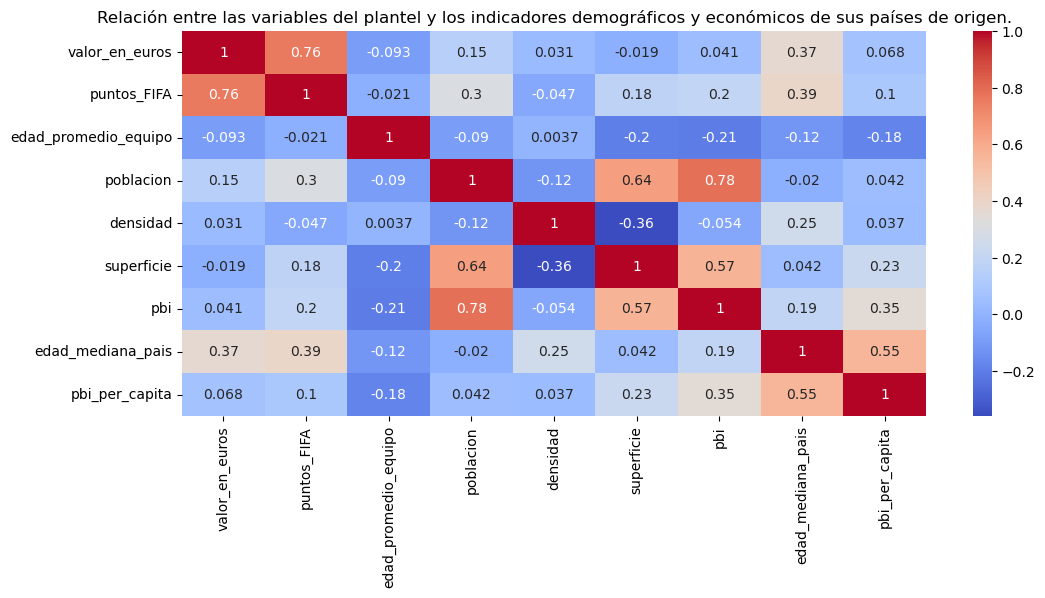

In [63]:
numerico_df = df_filtrado.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 5))
sns.heatmap(numerico_df.corr(), annot=True, cmap='coolwarm')
plt.title("Relación entre las variables del plantel y los indicadores demográficos y económicos de sus países de origen.")
plt.savefig("imagenes/heatmap-relacion-variables-numericas.png")

plt.show()


Conclusión: Hay una correlación fuerte entre el puntaje FIFA y el valor estimado del equipo.  
Estos valores, sin embargo, no tienen ninguna correlación con los estadísticos del país que consideramos.  
Vamos a hacer entonces un scatterplot para ver qué relación tienen estas dos variables.  


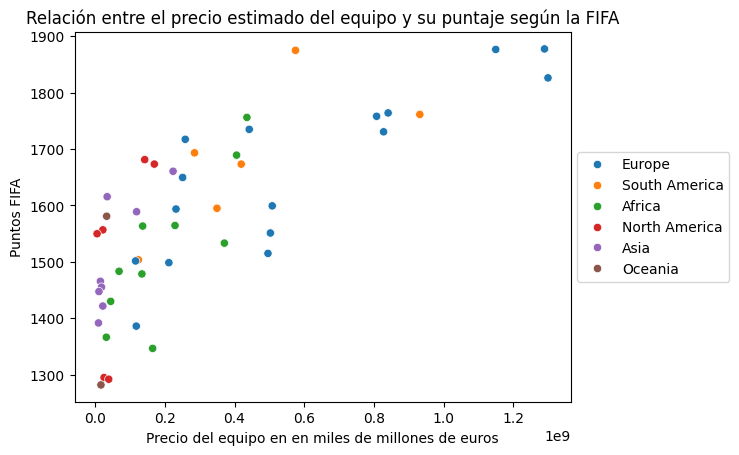

In [ ]:
sns.scatterplot(
    data=df_paises_f, #recupero el df anterior, no necesito filtrar a Escocia e Inglaterra ya
    x='valor_en_euros', 
    y="puntos_FIFA",
    hue='continente', #el color lo da el continente
    legend="full" #pone la leyenda
)
plt.title("Relación entre el precio estimado del equipo y su puntaje según la FIFA")
plt.xlabel('Precio del equipo en en miles de millones de euros')
plt.ylabel("Puntos FIFA")
plt.legend(bbox_to_anchor=(1, 0.5), loc='center left')
plt.savefig("imagenes/scattermap-puntajefifa-precioestimado.png")

plt.show()

Vemos que hay un equipo que parece lejano a la curva, aislamos los primeros 6 equipos para ver de qué país se trata:

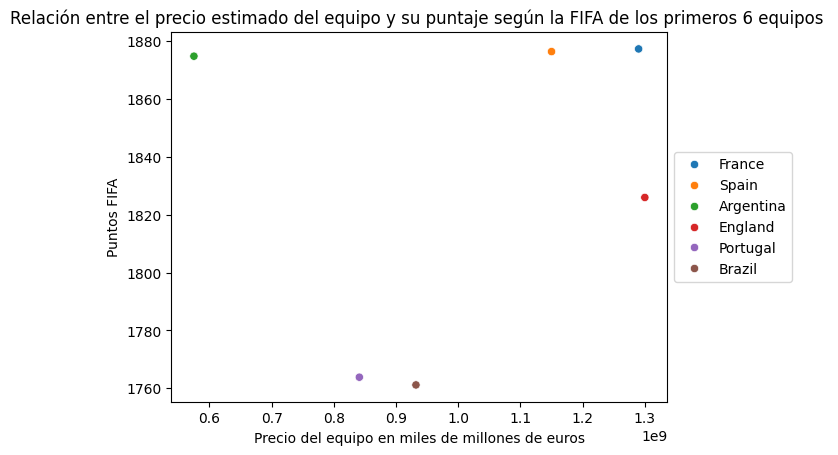

In [367]:
sns.scatterplot(
    data=df_paises_f.head(6), #detalle de los primeros 6 paises
    x='valor_en_euros', 
    y="puntos_FIFA",
    hue="pais", #el color lo da el pais
    legend="full" #pone la leyenda
)
plt.title("Relación entre el precio estimado del equipo y su puntaje según la FIFA de los primeros 6 equipos ")
plt.xlabel('Precio del equipo en miles de millones de euros')
plt.ylabel("Puntos FIFA")
plt.legend(bbox_to_anchor=(1, 0.5), loc='center left')
plt.savefig("imagenes/scattermap-puntajefifa-precioestimado-primeros6.png")

plt.show()

Conclusión: El país que parecía excepcional, por tener un precio de mercado muy inferior a lo que su puntaje indica es Argentina.  
Esto indica que Argentina tiene un desempeño mucho mejor que lo que se esperaría por el valor de sus jugadores. Múltiples motivos podrían explicar esta excepcionalidad: por ejemplo, un gran desempeño del equipo técnico, generando un equipo con sinergias que superan el valor agregado de sus jugadores.  

## Análisis por variables categóricas
### Continente:

Para ver si el continente de origen afecta el desempeño obtenemos el promedio de los Puntos FIFA de cada uno en base a los paises participantes.

In [368]:
df_continent = df_paises_f.groupby("continente").agg(PuntosFIFA=("puntos_FIFA", "mean"),Cantidad_paises=("puntos_FIFA", "count"))
df_continent

,PuntosFIFA,Cantidad_paises
continente,,
Africa,1520.891000,10
Asia,1505.588750,8
Europe,1661.044375,16
North America,1507.773333,6
Oceania,1431.120000,2
South America,1683.401667,6


Generamos un boxplot que muestre la distribución de puntos FIFA por continente.

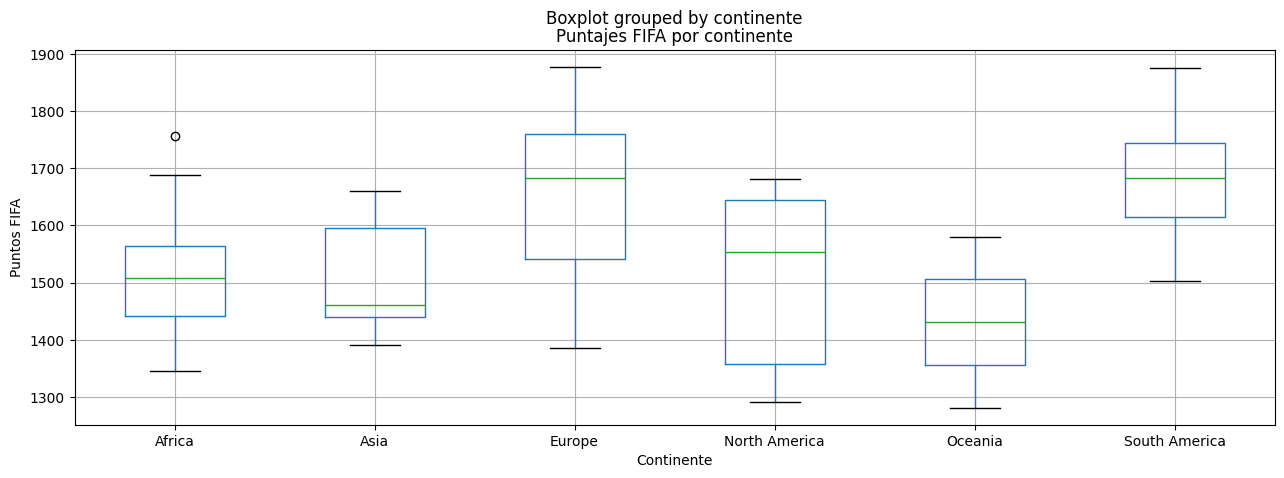

In [369]:
df_paises_f.boxplot('puntos_FIFA', 'continente', figsize=(15, 5), grid=True)
plt.title("Puntajes FIFA por continente")
plt.xlabel("Continente")
plt.ylabel("Puntos FIFA")
plt.savefig("imagenes/boxplot-puntajefifa-continente.png")

plt.show()

Conclusión: El continente de origen del país sí parece ser un indicador importante del puntaje del equipo. América del Sur y Europa tienen puntajes superiores a los del resto. Posibles explicaciones: la competencia intra continental obliga a subir el nivel.

### Religión
Visualizamos cómo están distribuidas las religiones con un gráfico de Torta, y comparamos los rendimientos de las distintas religiones con un Boxplot.

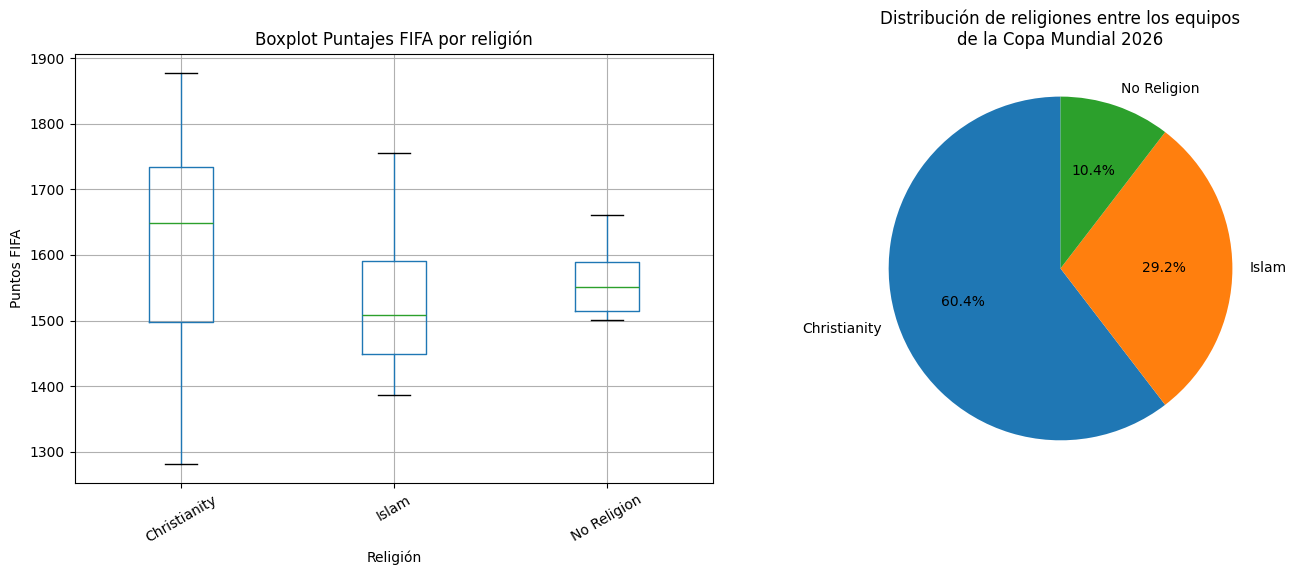

In [370]:
#Gráfico combinado

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

#Boxplot 
df_paises_f.boxplot('puntos_FIFA', 'religion', ax=ax1, grid=True)
ax1.set_title("Boxplot Puntajes FIFA por religión")
ax1.set_xlabel("Religión")
ax1.set_ylabel("Puntos FIFA")
ax1.tick_params(axis='x', rotation=30)

#Pie chart 
religion_count = df_paises_f["religion"].value_counts()
ax2.pie(
    religion_count,
    labels=religion_count.index,
    autopct="%1.1f%%",
    startangle=90,
)
ax2.set_title("Distribución de religiones entre los equipos\nde la Copa Mundial 2026")

plt.suptitle("")

plt.tight_layout()
plt.savefig("imagenes/boxplot-piechart-religiones.png", dpi=150, bbox_inches="tight")
plt.show()

La mayoría de los países que participan del torneo son de tradición cristiana, islámica o no presentan una religión predominante, mientras que no se observan países mayoritariamente budistas, hindúes o judíos. Dado que los países cristianos constituyen el grupo más numeroso, es esperable que presenten una mayor dispersión en los valores analizados. Sin embargo, también exhiben una mediana superior, lo que sugiere una posible asociación entre la religión predominante y otras características demográficas, culturales o geográficas. 

### Idioma
Hacemos un boxplot para ver si se ve una diferencia por idioma también.

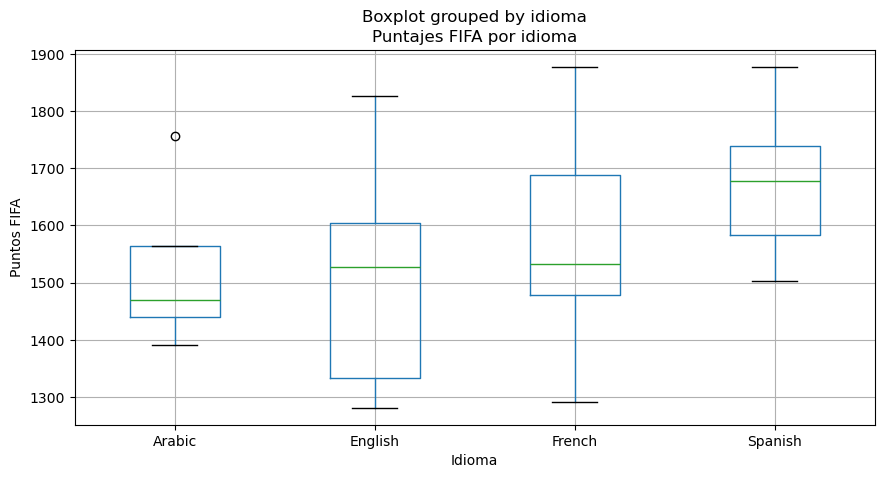

In [69]:
#uso IA para filtrar y solo tomar los idiomas que tengan más de 3 paises, para que el gráfico sea legible.
#prompt: "Quiero hacer un boxplot de puntajes FIFA por idioma, pero hay muchos idiomas con solo 1 o 2 países, lo que hace que el gráfico sea difícil de leer. 
#Filtrar el dataframe para quedarme solo con los idiomas que tengan más de 3 países."

df_paises_f_2 = df_paises_f.groupby('idioma').filter(lambda x: len(x) > 3)

df_paises_f_2.boxplot('puntos_FIFA', 'idioma', figsize=(10, 5), grid=True)
plt.title("Puntajes FIFA por idioma")
plt.xlabel("Idioma")
plt.ylabel("Puntos FIFA")
plt.savefig("imagenes/boxplot-puntajefifa-idioma.png")

plt.show()

Conclusión: parece haber una tendencia notable en los países de habla hispana a tener un puntaje más elevado en promedio que en otros países. El resultado no es sorprendente considerando que el continente de Sudamérica también tiene puntaje más alto que la media; seguramente haya una explicación cultural que explica ambos fenómenos.

# Análisis de la relación entre puntos FIFA y valor del equipo
El análisis exploratorio mostró una correlación fuerte solamente entre el valor de mercado del plantel y el puntaje FIFA (r = 0,77). El siguiente paso es modelar la forma que toma esa relación.

El objetivo es analizar cómo es la curva que une el puntaje FIFA y el valor estimado del equipo. Visualmente parece ser una curva cóncava hacia abajo. Para evaluar y encontrar la curva que mejor se ajusta, utilizamos Claude (Anthropic) para evaluar de entre cuatro modelos funcionales (lineal, logarítmico, potencia y cuadrático) cuál se ajusta mejor a los datos.

>Prompt utilizado: 
> "Evaluá modelos lineal, logarítmico, potencia y cuadrático para ajustar la relación entre valor de plantel (x) y puntaje FIFA (y). Compará por R² y calculá las derivadas analíticas con sympy."

## Modelos a evaluar

Probamos los siguientes **cuatro modelos funcionales** sobre los mismos datos y evaluamos su ajuste a los datos comparando sus coeficiente de determinación R²:  

| Modelo | Función |
|---|---|
| Lineal | $$f(x) = mx + b$$ |
| Logarítmico | $$f(x) = a \cdot ln(x) + b$$ |
| Potencia | $$f(x) = axᵇ$$ |
| Cuadrático | $$f(x) = ax² + bx + c$$ |

── Comparación de modelos por R² ────────────────────────────────
     Modelo     R²
 Cuadrático 0.6292
     Lineal 0.5902
   Potencia 0.5681
Logarítmico 0.5517

Mejor ajuste: Cuadrático (R²=0.629)


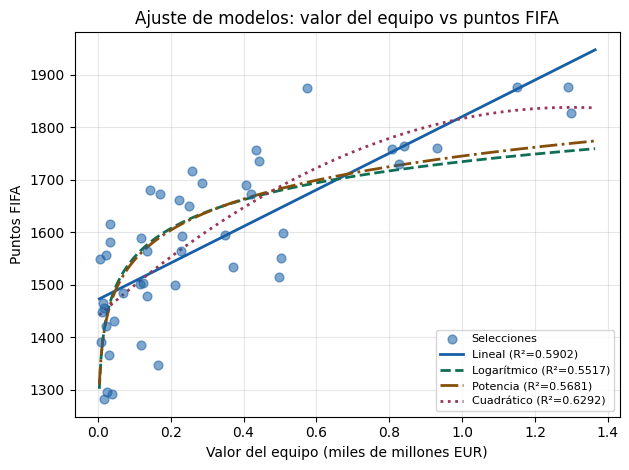

In [ ]:
# Esta celda cuenta con asistencia de IA (prompt detallado anteriormente)
# Ajuste de curvas: relación entre valor del equipo y puntaje FIFA

# ── Definición de modelos ──────────────────────────────────────────────────

def modelo_lineal(x, m, b):
    """f(x) = m·x + b"""
    return m * x + b

def modelo_logaritmico(x, a, b):
    """f(x) = a·ln(x) + b"""
    return a * np.log(x) + b

def modelo_potencia(x, a, b):
    """f(x) = a · x^b"""
    return a * np.power(x, b)

def modelo_cuadratico(x, a, b, c):
    """f(x) = a·x² + b·x + c"""
    return a * x**2 + b * x + c


# ── Preparación de datos ───────────────────────────────────────────────────

# ajuste: normalizamos x dividiéndolo por 1.000.000.000
# El motivo: los valores originales están en euros (ej: 575.000.000).
# Al elevarlos al cuadrado en el modelo cuadrático, se obtienen números del
# orden de 10^17, lo que hace que curve_fit no converja correctamente.
# Expresar x en miles de millones (ej: 0.575) resuelve el problema
# sin perder información — solo cambia la escala.

x_raw = df_paises_f["valor_en_euros"].values
y     = df_paises_f["puntos_FIFA"].values
x     = x_raw / 1_000_000_000          # ← x ahora está en miles de millones de EUR


# ── Ajuste de los cuatro modelos ──────────────────────────────────────────
# curve_fit busca los parámetros que minimizan el error cuadrático entre la curva y los datos reales.

params_lin,  _ = curve_fit(modelo_lineal,      x, y)
params_log,  _ = curve_fit(modelo_logaritmico, x, y)
params_pow,  _ = curve_fit(modelo_potencia,    x, y, p0=[1500, 0.3], maxfev=5000)
params_cuad, _ = curve_fit(modelo_cuadratico,  x, y)

modelos = {
    "Lineal":      (modelo_lineal,      params_lin),
    "Logarítmico": (modelo_logaritmico, params_log),
    "Potencia":    (modelo_potencia,    params_pow),
    "Cuadrático":  (modelo_cuadratico,  params_cuad),
}

# ── R² para cada modelo ────────────────────────────────────────────────────
# R² = 1 - SS_res/SS_tot mide qué proporción de la varianza del puntaje FIFA logra explicar el modelo. 
# Cuanto más cerca de 1, mejor es el ajuste.

def r_cuadrado(y_real, y_pred):
    """Coeficiente de determinación R².
    Parámetros:
    y_real: valores reales de y
    y_pred: valores predichos por el modelo
    Retorna: el valor de R², que indica qué tan bien el modelo explica la variabilidad de los datos"""
    ss_res = np.sum((y_real - y_pred) ** 2)
    ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)
    return 1 - ss_res / ss_tot

modelos = {
    "Lineal":       (modelo_lineal,      params_lin),
    "Logarítmico":  (modelo_logaritmico, params_log),
    "Potencia":     (modelo_potencia,    params_pow),
    "Cuadrático":   (modelo_cuadratico,  params_cuad),
}

resultados = [
    {"Modelo": nombre, "R²": round(r_cuadrado(y, fn(x, *params)), 4)}
    for nombre, (fn, params) in modelos.items()
]

df_resultados = pd.DataFrame(resultados).sort_values("R²", ascending=False)

# El mejor modelo es el de mayor R²
# Guardamos su R² para reutilizarlo en las etiquetas de los gráficos siguientes en lugar de escribirlo a mano.

mejor_modelo = df_resultados.iloc[0]["Modelo"]
r2_cuad      = float(df_resultados.loc[df_resultados["Modelo"] == "Cuadrático", "R²"].values[0])

print("── Comparación de modelos por R² ────────────────────────────────")
print(df_resultados.to_string(index=False))
print(f"\nMejor ajuste: {mejor_modelo} (R²={r2_cuad:.3f})")

# ── Gráfico comparativo: curvas ajustadas  ─────────────────────

x_curve = np.linspace(x.min() * 0.8, x.max() * 1.05, 300)

colores = {
    "Lineal":      "#185FA5",
    "Logarítmico": "#0F6E56",
    "Potencia":    "#854F0B",
    "Cuadrático":  "#993556",
}
estilos = {
    "Lineal":      "-",
    "Logarítmico": "--",
    "Potencia":    "-.",
    "Cuadrático":  ":",
}

plt.scatter(x, y, color="#185FA5", alpha=0.55, s=40, zorder=3, label="Selecciones")

for nombre, (fn, params) in modelos.items():
    r2 = df_resultados.loc[df_resultados["Modelo"] == nombre, "R²"].values[0]
    plt.plot(x_curve, fn(x_curve, *params),
             color=colores[nombre], ls=estilos[nombre], lw=2,
             label=f"{nombre} (R²={r2})")

plt.title("Ajuste de modelos: valor del equipo vs puntos FIFA")
plt.xlabel("Valor del equipo (miles de millones EUR)")
plt.ylabel("Puntos FIFA")
plt.legend(fontsize=8, loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig("imagenes/ajuste_4_modelos.png", dpi=150, bbox_inches="tight")

plt.show()

Una vez identificado el mejor modelo, calculamos sus primera y segunda derivadas con `sympy`. La derivada f'(x) mide el rendimiento marginal: cuántos puntos FIFA adicionales se obtienen por cada €100M extra invertidos en el plantel, según el nivel de inversión puntual del equipo.

In [373]:
# Esta celda cuenta con asistencia de IA (prompt detallado anteriormente)
# ── Derivadas analíticas con sympy ────────────────────────────────────────
# Expresamos cada modelo como función simbólica para derivarlo de forma exacta.
# La derivada f'(x) mide el rendimiento marginal: cuántos puntos FIFA adicionales se obtienen por cada unidad extra de inversión, según el nivel de inversión.

xv = sp.Symbol("x", positive=True)

f_cuad = params_cuad[0] * xv**2 + params_cuad[1] * xv + params_cuad[2] # f(x) = a·x² + b·x + c


# Primera y segunda derivada del modelo ganador
deriv_cuad     = sp.diff(f_cuad, xv)     # f'(x)  = 2a·x + b
seg_deriv_cuad = sp.diff(deriv_cuad, xv)      # f''(x) = 2a  (constante)
val_seg_deriv  = float(seg_deriv_cuad.evalf())

# ── Resumen del análisis diferencial ──────────────────────────────────────
print("── Modelo cuadrático: análisis diferencial completo ─────────────────")
print(f"  f(x)   = {round(a_c, 2)}·x² + {round(b_c, 2)}·x + {round(c_c, 2)}")
print(f"  f'(x)  = {round(2*a_c, 2)}·x + {round(b_c, 2)}")
print(f"  f''(x) = {round(2*a_c, 2)}")
print(f"\n  Valor numérico de f''(x): {val_seg_deriv:.2f}  (constante en todo el dominio)")
print(f"  Signo: {'negativo → concavidad hacia abajo' if val_seg_deriv < 0 else 'positivo'}")


── Modelo cuadrático: análisis diferencial completo ─────────────────
  f(x)   = -235.37·x² + 612.27·x + 1439.44
  f'(x)  = -470.74·x + 612.27
  f''(x) = -470.74

  Valor numérico de f''(x): -470.74  (constante en todo el dominio)
  Signo: negativo → concavidad hacia abajo


Vamos a graficar las derivadas:

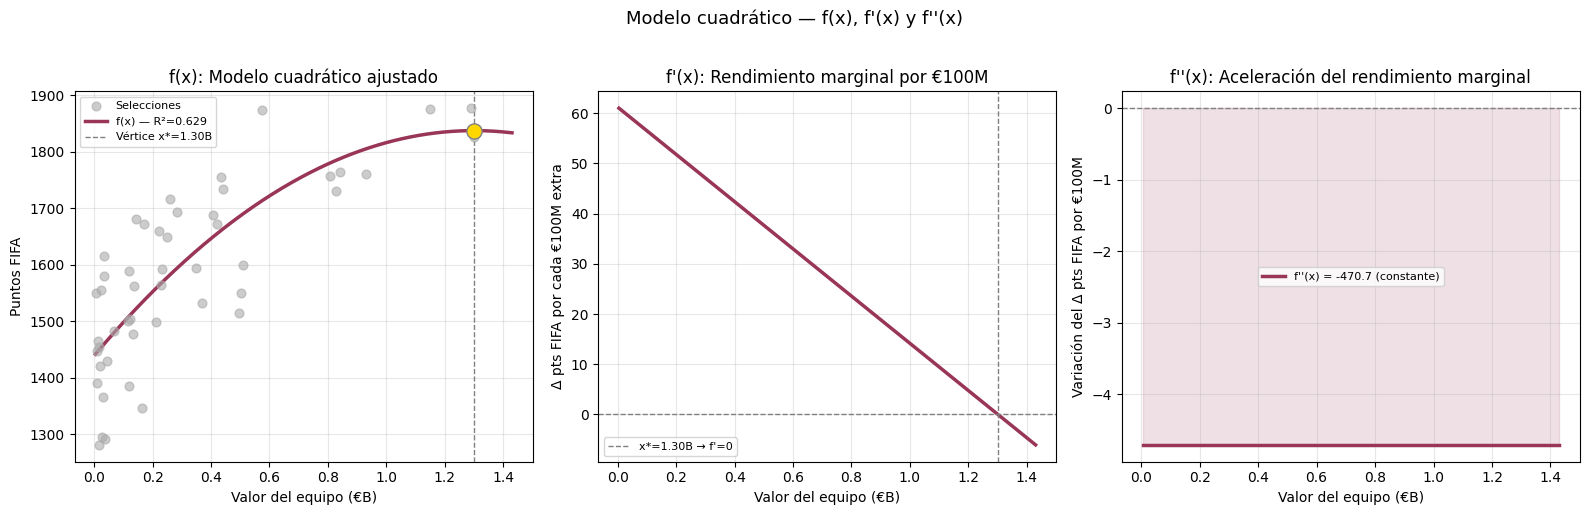

In [374]:
# Esta celda cuenta con asistencia de IA (prompt detallado anteriormente)
# ── Gráfico: f(x), f'(x) y f''(x) en tres paneles ─────────────────────────
x_curve_cuad = np.linspace(x.min() * 0.8, x.max() * 1.1, 300)

y_fx   = modelo_cuadratico(x_curve_cuad, *params_cuad)                          # f(x)
y_fpx  = [float(deriv_cuad.evalf(subs={xv: v})) * 0.1 for v in x_curve_cuad]    # f'(x) por €100M
y_fppx = [val_seg_deriv * 0.01] * len(x_curve_cuad)                            # f''(x) constante

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
COLOR = "#993556"

# Panel 1: curva ajustada f(x) con su vértice
ax1 = axes[0]
ax1.scatter(x, y, color="#AAAAAA", alpha=0.6, s=40, zorder=3, label="Selecciones")
ax1.plot(x_curve_cuad, y_fx, color=COLOR, lw=2.5, label=f"f(x) — R²={r2_cuad:.3f}")
ax1.axvline(x_vertice, color="gray", ls="--", lw=1, label=f"Vértice x*={x_vertice:.2f}B")
ax1.scatter([x_vertice], [y_vertice], color="gold", edgecolors="gray", s=120, zorder=5)
ax1.set_title("f(x): Modelo cuadrático ajustado")
ax1.set_xlabel("Valor del equipo (€B)")
ax1.set_ylabel("Puntos FIFA")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Panel 2: primera derivada f'(x) — cruza el cero justo en el vértice
ax2 = axes[1]
ax2.plot(x_curve_cuad, y_fpx, color=COLOR, lw=2.5)
ax2.axhline(0, color="gray", lw=1, ls="--")
ax2.axvline(x_vertice, color="gray", ls="--", lw=1, label=f"x*={x_vertice:.2f}B → f'=0")
ax2.set_title("f'(x): Rendimiento marginal por €100M")
ax2.set_xlabel("Valor del equipo (€B)")
ax2.set_ylabel("Δ pts FIFA por cada €100M extra")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Panel 3: segunda derivada f''(x) — constante (concavidad uniforme)
ax3 = axes[2]
ax3.plot(x_curve_cuad, y_fppx, color=COLOR, lw=2.5,
         label=f"f''(x) = {val_seg_deriv:.1f} (constante)")
ax3.axhline(0, color="gray", lw=1, ls="--")
ax3.fill_between(x_curve_cuad, y_fppx, 0, alpha=0.15, color=COLOR)
ax3.set_title("f''(x): Aceleración del rendimiento marginal")
ax3.set_xlabel("Valor del equipo (€B)")
ax3.set_ylabel("Variación del Δ pts FIFA por €100M")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.suptitle("Modelo cuadrático — f(x), f'(x) y f''(x)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("imagenes/segunda_derivada_cuadratico.png", dpi=150, bbox_inches="tight")
plt.show()


## Ecuación, derivada y vértice

**La ecuación del modelo ganador: $$f(x) = ax² + bx + c$$**
$$f(x)   = -235.37x² + 612.27x + 1439.44$$
El coeficiente negativo del término cuadrático (a < 0) es el hallazgo clave del 
ajuste: la parábola se abre hacia abajo, lo que implica que la relación entre 
inversión en plantel y puntaje FIFA tiene un límite natural. Los puntos crecen 
al invertir más, pero a una tasa que se desacelera progresivamente hasta 
revertirse pasado el vértice.

**La derivada: $$f'(x) = 2ax + b$$**  
$$f'(x)  = -470.74·x + 612.27$$
En el modelo cuadrático la derivada es una función decreciente de x. Esto formaliza el concepto de rendimientos 
marginales decrecientes: para equipos con bajo gasto, cada €100M adicionales 
generan muchos puntos FIFA; para equipos con alto gasto, la misma inversión 
produce progresivamente menos. La derivada f'(x) cuantifica esta diferencia 
con precisión.

**La segunda derivada: $$f''(x) = 2a$$**
$$f''(x) ≈ −471 (constante)$$
La segunda derivada del modelo cuadrático es un número constante, igual a
2 veces el coeficiente cuadrático ajustado. Su signo negativo confirma que
la parábola es cóncava hacia abajo en todo su dominio. 

Buscamos entonces el punto crítico, que sabemos que va a ser un máximo, dado que la f'' es <0.

In [375]:
# Esta celda cuenta con asistencia de IA (prompt detallado anteriormente)
# ── Punto crítico del modelo cuadrático ─────────────────────────────────────────
# El punto crítico es el punto donde f'(x) = 0, es decir x* = -b/(2a). 
# Como f''(x)  < 0, sabenos que este punto crítico es un máximo. 
# Representa el nivel de inversión a partir del cual gastar más deja de sumar puntos.

a_c, b_c, c_c = params_cuad
x_vertice = -b_c / (2 * a_c)
y_vertice = modelo_cuadratico(x_vertice, a_c, b_c, c_c)

print(f"\n── Vértice del modelo cuadrático ────────────────────────────────")
print(f"  Inversión óptima : €{x_vertice:.3f} miles de millones")
print(f"  Puntaje máximo   : {y_vertice:.1f} puntos FIFA")
print(f"  Interpretación   : por encima de este valor, invertir más deja")
print(f"                     de traducirse en mejora de puntaje FIFA.")



── Vértice del modelo cuadrático ────────────────────────────────
  Inversión óptima : €1.301 miles de millones
  Puntaje máximo   : 1837.6 puntos FIFA
  Interpretación   : por encima de este valor, invertir más deja
                     de traducirse en mejora de puntaje FIFA.



### El máximo como umbral de eficiencia 
El vértice de la parábola representa el nivel de inversión donde f'(x) = 0 y está ubicado en 
$$x = -b/(2a) ≈ €1,30B$$
Es el punto de máximo rendimiento según el modelo.
Francia (€1,29B) e Inglaterra (€1,30B) se ubican prácticamente sobre ese punto, 
lo que sugiere que las selecciones europeas de élite operan en el límite de la 
eficiencia de inversión — o incluso lo han superado.

Por último nos interesa ver cuánto se acerca la curva a los valores reales. Para ello calculamos el "residuo": la diferencia entre el valor que predice el modelo contra el valor real. Este valor nos da una idea de cuáles son los equipos que tienen una performance mejor que la que su valor indicaría y viceversa.

In [376]:
# Esta celda cuenta con asistencia de IA (prompt detallado anteriormente)
# ── Residuos del modelo cuadrático ────────────────────────────────────────
# residuo = puntaje real - puntaje predicho. Un residuo positivo indica que el equipo rinde por encima de lo que su inversión predice. 

df_paises_f["x_b"]     = df_paises_f["valor_en_euros"] / 1_000_000_000
df_paises_f["y_pred"]  = modelo_cuadratico(df_paises_f["x_b"], a_c, b_c, c_c)
df_paises_f["residuo"] = df_paises_f["puntos_FIFA"] - df_paises_f["y_pred"]

print(f"\nCinco países que rinden más por encima de lo que su inversión predice (están subvaluados):")
print(df_paises_f[["pais", "residuo"]].sort_values("residuo", ascending=False).head(5))
print(f"\nCinco países que rinden más por debajo de lo que su inversión predice (están sobrevaluados):")
print(df_paises_f[["pais", "residuo"]].sort_values("residuo", ascending=False).tail(5))


Cinco países que rinden más por encima de lo que su inversión predice (están subvaluados):
             pais     residuo
2       Argentina  161.127952
13         Mexico  159.333958
18           Iran  155.160895
14  United States  136.560773
10        Croatia  135.080774

Cinco países que rinden más por debajo de lo que su inversión predice (están sobrevaluados):
           pais     residuo
45      Curaçao -160.182745
47  New Zealand -167.870987
30       Sweden -170.449405
46        Haiti -171.107009
44        Ghana -187.698345


Vamos a graficar algunos de los equipos que más se alejan de la curva, para ver donde se ubican.

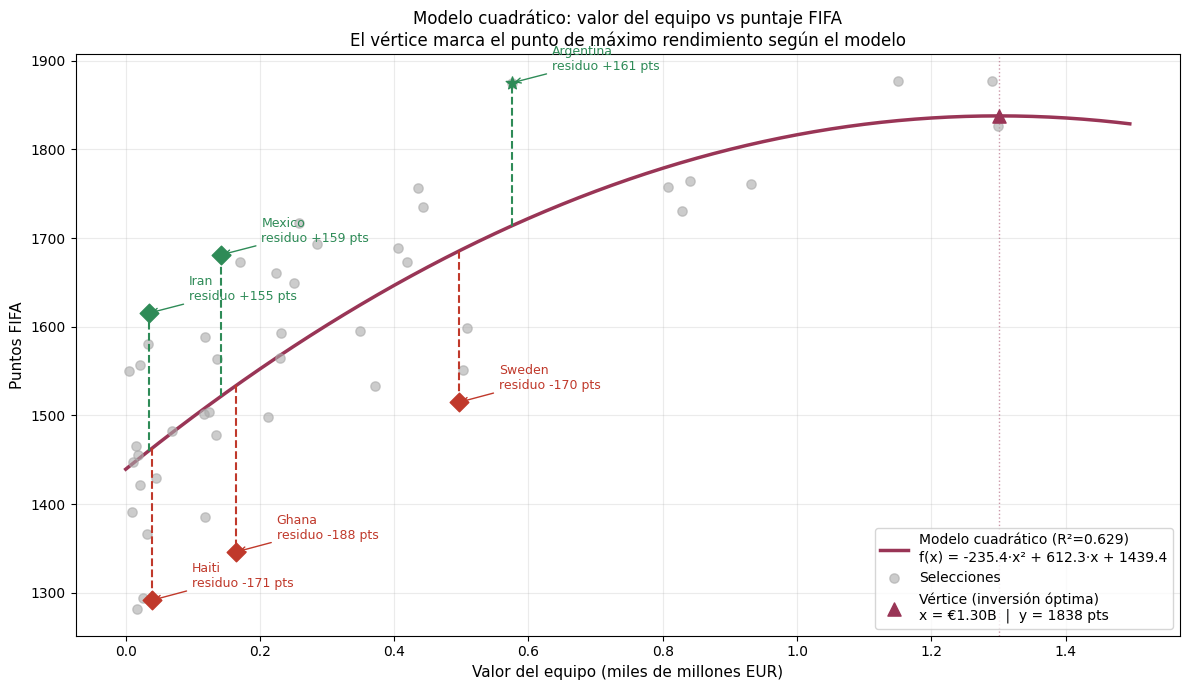

In [377]:
# Esta celda cuenta con asistencia de IA (prompt detallado anteriormente)

# Modelo cuadrático con vértice, residuos y casos destacados

fig, ax = plt.subplots(figsize=(12, 7))

# Curva del modelo cuadrático ajustado
x_curve = np.linspace(0, x_vertice * 1.15, 300)
ax.plot(
    x_curve,
    modelo_cuadratico(x_curve, a_c, b_c, c_c),
    color="#993556", lw=2.5, zorder=2,
    label=f"Modelo cuadrático (R²={r2_cuad:.3f})\nf(x) = {a_c:.1f}·x² + {b_c:.1f}·x + {c_c:.1f}"
)

# Todos los equipos (puntos grises)
ax.scatter(
    df_paises_f["x_b"], df_paises_f["puntos_FIFA"],
    color="#AAAAAA", alpha=0.6, s=45, zorder=3, label="Selecciones"
)

# Casos destacados: se marca cada equipo y su residuo (distancia vertical al
# modelo), reutilizando las columnas y_pred y residuo ya calculadas.
casos = {
    "Argentina": {"color": "#2E8B57", "marker": "*", "size": 90}, #ponemos los tres con mayor residuo positivo
    "Mexico":    {"color": "#2E8B57", "marker": "D", "size": 90},
    "Iran":   {"color": "#2E8B57", "marker": "D", "size": 90},
    "Ghana":   {"color": "#C0392B", "marker": "D", "size": 90}, #ponemos los tres con mayor residuo negativo 
    "Haiti":   {"color": "#C0392B", "marker": "D", "size": 90},
    "Sweden":   {"color": "#C0392B", "marker": "D", "size": 90},
}
for pais, estilo in casos.items():
    fila = df_paises_f[df_paises_f["pais"] == pais].iloc[0]
    ax.scatter(
        fila["x_b"], fila["puntos_FIFA"],
        color=estilo["color"], marker=estilo["marker"], s=estilo["size"], zorder=5
    )
    # Línea punteada que representa el residuo (real vs predicho)
    ax.plot(
        [fila["x_b"], fila["x_b"]],
        [fila["y_pred"], fila["puntos_FIFA"]],
        color=estilo["color"], lw=1.5, ls="--", zorder=4
    )
    signo = "+" if fila["residuo"] > 0 else ""
    ax.annotate(
        f"{pais}\nresiduo {signo}{fila['residuo']:.0f} pts",
        xy=(fila["x_b"], fila["puntos_FIFA"]),
        xytext=(fila["x_b"] + 0.06, fila["puntos_FIFA"] + 15),
        fontsize=9, color=estilo["color"],
        arrowprops=dict(arrowstyle="->", color=estilo["color"], lw=1)
    )

# Vértice (máximo del modelo) y zona de rendimientos decrecientes a su derecha
ax.scatter(
    x_vertice, y_vertice,
    color="#993556", marker="^", s=90, zorder=5,
    label=f"Vértice (inversión óptima)\nx = €{x_vertice:.2f}B  |  y = {y_vertice:.0f} pts"
)
ax.axvline(x_vertice, color="#993556", lw=1, ls=":", alpha=0.5)


ax.set_title(
    "Modelo cuadrático: valor del equipo vs puntaje FIFA\n"
    "El vértice marca el punto de máximo rendimiento según el modelo",
    fontsize=12
)
ax.set_xlabel("Valor del equipo (miles de millones EUR)", fontsize=11)
ax.set_ylabel("Puntos FIFA", fontsize=11)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("imagenes/modelo_cuadratico_vertice.png", dpi=150, bbox_inches="tight")
plt.show()

**Los factores no monetarios como ventaja competitiva**  
El residuo positivo de Argentina (+161 pts) es el mayor del dataset, pero no es un caso aislado: lo acompañan México (+159), Irán (+155), Estados Unidos (+137) y Croacia (+135). Todos son planteles de valor bajo o medio (por debajo del vértice de €1,30B) que rinden muy por encima de lo que su inversión predice. Esto nos da la pauta de que hay factores no capturados por el valor de mercado —cohesión táctica, continuidad del cuerpo técnico, experiencia en torneos— que compensan la menor inversión y constituyen una ventaja competitiva real e independiente del gasto.

**La dispersión se concentra en los planteles de bajo valor**  
Los residuos negativos más grandes —Ghana (−188), Haití (−171), Suecia (−170), Nueva Zelanda (−168) y Curaçao (−160)— también corresponden, salvo Suecia, a planteles de valor muy bajo (x ≈ 0). Es decir que tanto los mayores sobre-rendimientos como los mayores sub-rendimientos aparecen donde el valor de plantel apenas varía. Esto revela una limitación del modelo: cuando la inversión es baja, el valor de mercado prácticamente no discrimina entre selecciones, y el puntaje FIFA se dispersa fuertemente en ambas direcciones por motivos que la variable no recoge. La desviación estándar de los residuos lo confirma: es mayor en la mitad de equipos con menos puntos (≈86 pts) que en la mitad superior (≈74 pts). En otras palabras, el modelo cuadrático ajusta razonablemente bien a las potencias consolidadas, pero pierde poder explicativo en el extremo de baja inversión, donde la dispersión es mayor y la relación inversión–rendimiento se vuelve mucho más ruidosa.

# **4. Conclusion**

El trabajo confirma que el rendimiento deportivo (medido por el puntaje FIFA) es independiente de las variables económicas del país: ninguna de ellas mostró correlación relevante con el desempeño. En cambio, encontramos dos hallazgos centrales:  
1.	Valor del plantel. Existe una correlación fuerte entre el valor de mercado del plantel y el puntaje FIFA (r ≈ 0,77). Al modelar la relación, el mejor ajuste fue cuadrático y cóncavo hacia abajo, lo que indica rendimientos marginales decrecientes: invertir más en el plantel mejora el puntaje, pero cada euro adicional aporta cada vez menos.  
2.	Variables culturales/geográficas. El continente de origen y el idioma se asocian al rendimiento (Sudamérica y Europa, y los países de habla hispana, presentan medianas más altas). Estas dimensiones probablemente capturan un mismo factor cultural subyacente y, en parte, se solapan entre sí.  
En conjunto, los resultados sugieren que el rendimiento de una selección no está determinado por la riqueza o el tamaño del país, sino que combina una base relativamente "fija" (asociada a factores culturales y geográficos) con un componente modificable mediante inversión en el plantel, sujeta a rendimientos decrecientes.